In [67]:
import pandas as pd
import os
from geneeanlpclient import g3
import requests
from dotenv import load_dotenv
from datetime import datetime
import time
import json
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt


In [34]:

load_dotenv()
geneeaKey = os.environ["GENEEA_USER_KEY"]
kaggleKey = os.environ["KAGGLE_KEY"]

In [35]:
def callGeneea(input):
    url = 'https://api.geneea.com/v3/analysis'
    headers = {
        'content-type': 'application/json',
        'Authorization': 'user_key ' + geneeaKey
    }
    return requests.post(url, json=input, headers=headers).json()

In [21]:
trueData = pd.read_csv("True.csv")
fakeData = pd.read_csv("Fake.csv")

In [22]:
trueData["date"] = pd.to_datetime(trueData["date"], errors="coerce", format="mixed")
fakeData["date"] = pd.to_datetime(fakeData["date"], errors="coerce", format="mixed")

In [25]:
trueData.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29


In [30]:
try:
    with open("Geneaa_Results_True.json") as f:
        trueGeneea = json.load(f)

    with open("SeenData.json") as f:
        seen = set(json.load(f))
except:
    trueGeneea = dict()
    seen = set()

In [37]:
target = datetime.strptime("03/28/2017", "%m/%d/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year)) & (trueData["date"].dt.day == target.day)]

In [98]:
def getGroupWithAttr(targetData, attr=None, outputTitle="out.json"):
    try:
        with open(outputTitle) as f:
            geneeaOut = json.load(f)
    except FileNotFoundError:
        geneeaOut = dict()

    seen = set(geneeaOut.keys())
  
    for _, each in targetData.iterrows():
        title = each['title']
        if (title in seen):
            continue
        
        doc = callGeneea({"text": each['text'], "analyses": attr})
        if "exception" in doc:
            print(doc.get("exception"))
            break
        geneeaOut[title] = doc
        seen.add(title)
        with open(outputTitle, "w") as f:
            json.dump(geneeaOut, f)
        time.sleep(0.5)

def getGroup(targetData, outputTitle):
    getGroupWithAttr(targetData, ['entities', 'tags', 'relations', 'sentiment'], outputTitle)

In [ ]:
getGroup(targetData, "Geneaa_Results_True.json")

In [108]:
loc_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "location":
                loc_count[e["stdForm"]] += 1

print(loc_count.keys())


dict_keys(['United States of America', 'Antigua and Barbuda', 'Dominican Republic', 'California', 'Macau', 'Manhattan', 'White House', 'San Francisco', 'New York', 'WASHINGTON', 'Massachusetts', 'Texas', 'Silicon Valley', 'Colorado', 'Russia', 'North Carolina', 'Trump Tower', 'Hawaii', 'New Hampshire', 'Washington state', 'Oregon', 'Indiana', 'Washington', 'District of Columbia', 'Virginia', 'China', 'Chicago', 'Philadelphia', 'Japan', 'India', 'Paris', 'Boulder', 'Montenegro', 'Europe', 'Moscow', 'Balkan', 'Balkans', 'Mexico', 'Mosul', 'Missouri', 'Wyoming', 'Montana', 'Powder River Basin', 'NEW YORK', 'Iran', 'Ankara', 'Syria', 'Turkey', 'Halkbank', 'Miami', 'Disney World', 'Arkansas', 'Idaho', 'Canada', 'New Jersey', 'Wisconsin', 'Brussels', 'United Kingdom', 'Estonia', 'Greece', 'Poland', 'Ukraine', 'Crimea', 'Ratpac', 'Hollywood', 'Kentucky', 'Hamburg', 'Germany', 'Saarland', 'Florida', 'Palm Beach', 'Capitol Hill', 'Arizona', 'Naco', 'Iraq', 'Libya', 'Somalia', 'Sudan', 'Yemen', 

In [104]:
person_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person":
                person_count[e["stdForm"]] += 1

print(person_count.items())

dict_items([('Bill Clinton', 3), ('Jeff Yin', 1), ('Ng Lap Seng', 1), ('Sabrina Shroff', 1), ('Ng', 1), ('John Ashe', 1), ('Francis Lorenzo', 1), ('Donald Trump', 196), ('Jeff Sessions', 6), ('Mike Pence', 15), ('Jim Pasco', 1), ('Barack Obama', 82), ('Ajit Pai', 5), ('Craig Aaron', 1), ('Michael Capuano', 1), ('Michael Burgess', 1), ('Mitch McConnell', 9), ('Neil Gorsuch', 14), ('Chuck Schumer', 11), ('John McCain', 4), ('Devin Nunes', 22), ('Paul Ryan', 30), ('Jared Kushner', 11), ('AshLee Strong', 2), ('Lindsey Graham', 2), ('Walter Jones', 2), ('Kevin McCarthy', 2), ('Scott Will', 1), ('Mark Herring', 1), ('Karl Racine', 1), ('Cynthia Coffman', 1), ('Bob Ferguson', 1), ('Sean Rankin', 1), ('Kevin Brady', 10), ('Bill Pascrell', 2), ('Pat Meehan', 1), ('Sander Levin', 1), ('Tyler White', 2), ('Eric Schneiderman', 2), ('Christiana Figueres', 2), ('Bill Becker', 1), ('Rex Tillerson', 13), ('Mike Lee', 3), ('Paul', 2), ('Jeanne Shaheen', 1), ('Roy Blunt', 1), ('Mario Diaz-Balart', 2), (

In [105]:
top5_people = {name for name, _ in person_count.most_common(5)}
person_count.most_common(5)

[('Donald Trump', 196),
 ('Barack Obama', 82),
 ('Obamacare', 36),
 ('Paul Ryan', 30),
 ('Devin Nunes', 22)]

{'Devin Nunes', 'Barack Obama', 'Obamacare', 'Paul Ryan', 'Donald Trump'}


Text(0, 0.5, 'Frequency')

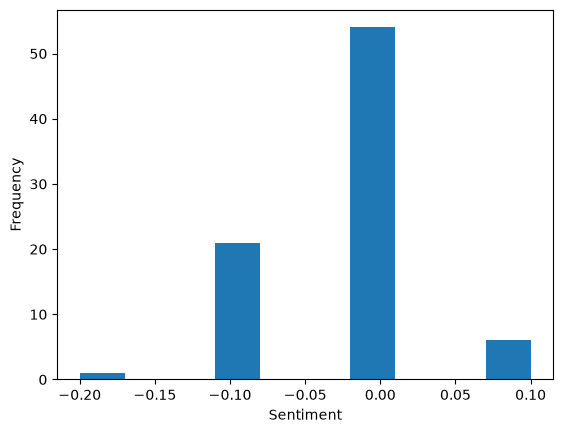

In [106]:
trueSent = []

for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person" and e["stdForm"] == "Barack Obama":
                trueSent.append(each.get("docSentiment").get("mean"))
                break


print(top5_people)
plt.hist(trueSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

In [99]:
target = datetime.strptime("03/2017", "%m/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year))]

getGroupWithAttr(targetData, ['entities', 'sentiment'], "Geneea_Results_True.json")

KeyboardInterrupt: 

In [100]:
with open("Geneea_Results_True.json") as f:
    trueGeneea = json.load(f)

len(trueGeneea)

247

In [85]:
full = callGeneea({"text": "Barack Obama visited Berlin last summer and loved it."})
print(full.keys())

dict_keys(['version', 'language', 'entities', 'tags', 'relations', 'docSentiment', 'usedChars'])
